In [1]:
import pandas as pd

In [2]:
import datetime as dt

In [3]:
start = dt.datetime(2021,6,1)
end=dt.datetime(2022,1,28)

In [4]:
df = pd.read_csv('Tatacoffee13_21.csv', index_col='Date', parse_dates=True)

In [5]:
df.head()


,Open,High,Low,Close
Date,,,,
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-07,1580.00,1639.50,1565.50,1595.65


In [6]:
stk_data = df

In [7]:
stk_data= df.loc[start:end]

In [8]:
column="Close"

In [9]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (145, 1)


In [10]:
training_size = round(len(data1 ) * 0.95)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

138
X_train length: (138, 1)
X_test length: (7, 1)
y_train length: (138, 1)
y_test length: (7, 1)


In [11]:
import warnings
warnings.filterwarnings("ignore")

In [12]:
from sklearn.metrics import root_mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

model=ARIMA(X_train, order=(0,0,10), trend='n')
model_fit=model.fit()

C:\Anaconda3\envs\aiml\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [13]:
print(len(X_train))

138


In [14]:
print(len(data1)-1)

144


In [15]:
y_pred = model_fit.predict(138, 144)

In [16]:
rmse=root_mean_squared_error(y_test,y_pred)

In [17]:
rmse

0.3737032135076217

In [18]:
from sklearn.metrics import mean_absolute_percentage_error

In [19]:
mape=mean_absolute_percentage_error(y_test,y_pred)

In [20]:
print(mape)

0.5804545519941137


In [21]:
# Creating loop to check how the model behaves for other parameter and evaluate rmse and mape metrics
trends=['n','t','c','ct']
orders=[(0,0,1),(0,0,2)]
for td in trends:
    for o in orders:
        model=ARIMA(X_train, order=o, trend=td)
        model_fit=model.fit()
        y_pred = model_fit.predict(len(X_train),len(data1)-1)  # This is prdicting similar length of series in y_test
        from stockFunctions import rmsemape # calling user defined function which contains metric calculation
        rmsemape(y_test,y_pred)
        print("_______________")

RMSE-Testset: 0.506484129461125
maPe-Testset: 0.9008470440123953
_______________
RMSE-Testset: 0.4971514570020969
maPe-Testset: 0.8488445028375765
_______________


C:\Anaconda3\envs\aiml\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RMSE-Testset: 0.3817220445353735
maPe-Testset: 0.7965679285461682
_______________


C:\Anaconda3\envs\aiml\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RMSE-Testset: 0.3596775265717679
maPe-Testset: 0.7425805157300646
_______________
RMSE-Testset: 0.11983736748948907
maPe-Testset: 0.17894908980092503
_______________
RMSE-Testset: 0.12142018000919941
maPe-Testset: 0.18208082513839824
_______________
RMSE-Testset: 0.29724821942234886
maPe-Testset: 0.6189244229514085
_______________
RMSE-Testset: 0.27823532498334985
maPe-Testset: 0.5753352872576194
_______________


In [22]:
len(y_pred)

7

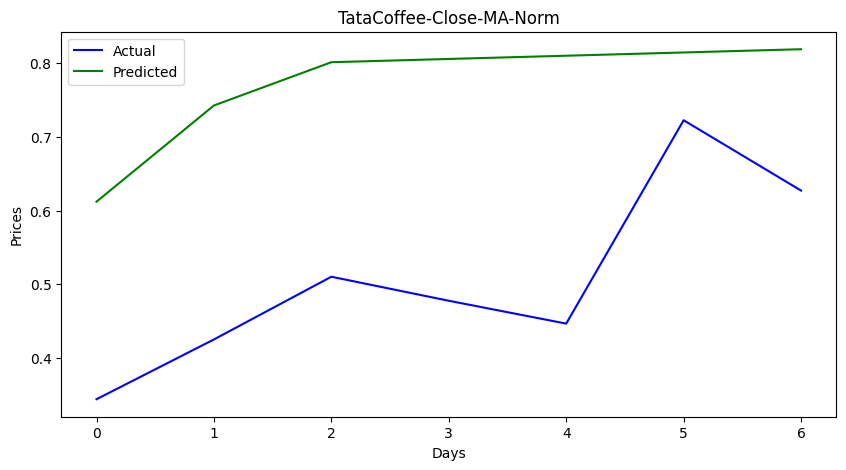

In [23]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Close-MA-Norm","Days","Prices")

In [24]:
len(data1)

145

In [28]:
len(y_train)

138

In [29]:
import pandas as pd
Actual_y_train=pd.DataFrame(index=range(len(y_train)),columns=[column])  #it creates dataframe with null value


In [30]:
Actual_y_train

,Close
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
133,NaN
134,NaN
135,NaN
136,NaN


In [32]:
# Assigning value to newly created DataFrame
for i in range(len(y_train)):
    Actual_y_train.iloc[i]=y_train[i]

In [33]:
Actual_y_train

,Close
0,0.021463
1,0.017488
2,0.060413
3,0.023052
4,0.023052
...,...
133,0.663752
134,0.636725
135,0.607313
136,0.554849


In [41]:
# Function does the same above for Acutal Test
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])  # this call creates data frame and fill with y_test value
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)  # this call inverse the scaler value from dataframe into original value. Scaler expects DataFrame data
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column]) #this call creates dataframe

In [37]:
aTestNormTable

,Close
0,0.344197
1,0.425278
2,0.510334
3,0.477742
4,0.446741
5,0.722576
6,0.627186


In [36]:
actual_stock_price_test_ori

array([[194.55],
       [199.65],
       [205.  ],
       [202.95],
       [201.  ],
       [218.35],
       [212.35]])

In [35]:
actual_stock_price_test_oriA

,Close
0,194.55
1,199.65
2,205.0
3,202.95
4,201.0
5,218.35
6,212.35


In [39]:
# Function does the same above for Predicted Test
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])  #Creating df for predicted value
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable) #inversing the scaler data into Original value 
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column]) # creating data frame.

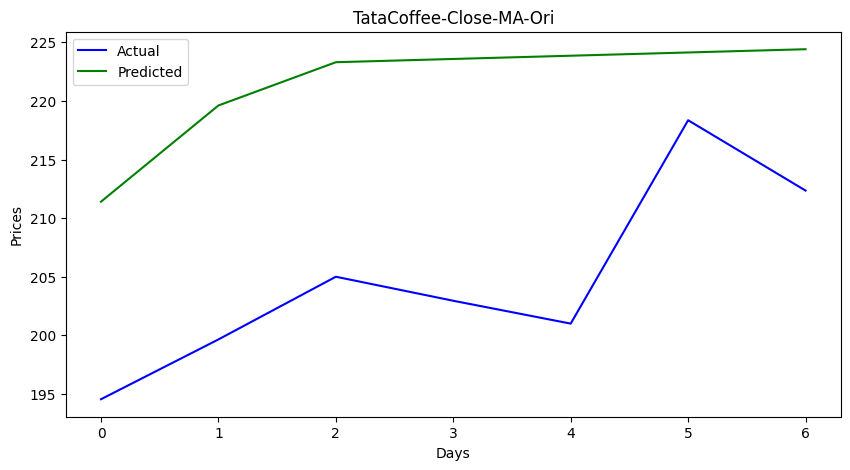

In [40]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-Close-MA-Ori","Days","Prices")

Both the above graphs are same. First one has prices in scaler value. Second one has prices in original value.

In [42]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 17.501001941452703
maPe-Testset: 0.08206845194244829


In [43]:
forecast=model_fit.predict(len(data1), len(data1))

In [44]:
forecast

array([0.82330422])

In [45]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [46]:
forecast_stock_price_test_oriF

,Closefore
0,224.685835


In [48]:
#Creating a file with predicted data
forecast_stock_price_test_oriF.to_csv("CloseMA.csv",index=False)  